<a href="https://colab.research.google.com/github/muppadivignesh-del/Machine-Learning_Lab_Experiments/blob/main/skil_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab/synthetic_student_performance.csv')

print("Dataset Shape:", df.shape)
display(df.head(10))

Mounted at /content/drive
Dataset Shape: (5000, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1
5,1006,18,0,3,4,13,23,1,2,1,0,1,0,4.000000,0
6,1007,15,1,0,3,14,25,0,2,1,0,1,1,3.009268,1
7,1008,15,0,0,4,11,8,0,3,0,0,1,1,4.000000,0
8,1009,17,1,1,1,11,23,0,2,0,0,0,0,3.944525,0
9,1010,16,1,3,4,7,11,0,3,0,1,1,1,2.735138,2


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nGrade Class Distribution:")
display(df["GradeClass"].value_counts().sort_index().to_frame("Count"))

Columns:
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Missing Values:


,Missing Values
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0



Grade Class Distribution:


,Count
GradeClass,
0,2175
1,1152
2,1023
3,650


In [3]:
features = [
    c for c in df.select_dtypes(include="number").columns
    if c not in ["StudentID", "GradeClass"]
]

X = df[features]
y = df["GradeClass"]

print("Features:")
print(features)

print("\nFeature Data:")
display(X.head())

Features:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']

Feature Data:


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,17,1,1,3,16,13,0,2,0,0,0,0,3.158425
1,18,1,2,0,17,28,0,2,1,1,1,0,2.794655
2,15,1,0,1,13,18,1,4,0,0,0,1,3.774847
3,17,1,0,3,6,4,0,3,1,0,0,0,3.040574
4,17,0,1,2,6,20,0,4,0,0,0,0,3.382310


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 4000
Testing Samples : 1000


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

gini_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_tree.fit(X_train, y_train)

gini_pred = gini_tree.predict(X_test)

gini_accuracy = accuracy_score(y_test, gini_pred)

print("===== GINI DECISION TREE =====")
print("Accuracy :", round(gini_accuracy, 4))
print("Tree Depth:", gini_tree.get_depth())
print("Leaves    :", gini_tree.get_n_leaves())

===== GINI DECISION TREE =====
Accuracy : 1.0
Tree Depth: 3
Leaves    : 4


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

gini_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_tree.fit(X_train, y_train)

gini_pred = gini_tree.predict(X_test)

gini_accuracy = accuracy_score(y_test, gini_pred)

print("===== GINI DECISION TREE =====")
print("Accuracy :", round(gini_accuracy, 4))
print("Tree Depth:", gini_tree.get_depth())
print("Leaves    :", gini_tree.get_n_leaves())

===== GINI DECISION TREE =====
Accuracy : 1.0
Tree Depth: 3
Leaves    : 4


In [9]:
entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_tree.fit(X_train, y_train)

entropy_pred = entropy_tree.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("===== ENTROPY DECISION TREE =====")
print("Accuracy :", round(entropy_accuracy, 4))
print("Tree Depth:", entropy_tree.get_depth())
print("Leaves    :", entropy_tree.get_n_leaves())

===== ENTROPY DECISION TREE =====
Accuracy : 1.0
Tree Depth: 3
Leaves    : 4


In [10]:
comparison = pd.DataFrame({
    "Splitting Criterion": ["Gini", "Entropy"],
    "Accuracy": [gini_accuracy, entropy_accuracy],
    "Tree Depth": [
        gini_tree.get_depth(),
        entropy_tree.get_depth()
    ],
    "Number of Leaves": [
        gini_tree.get_n_leaves(),
        entropy_tree.get_n_leaves()
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

display(comparison)

,Splitting Criterion,Accuracy,Tree Depth,Number of Leaves
0,Gini,1.0,3,4
1,Entropy,1.0,3,4


In [11]:
depths = range(1, 16)
depth_results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)
    pred = tree.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    depth_results.append([depth, accuracy])

depth_table = pd.DataFrame(
    depth_results,
    columns=["Max Depth", "Accuracy"]
)

depth_table["Accuracy"] = depth_table["Accuracy"].round(4)

display(depth_table)

,Max Depth,Accuracy
0,1,0.665
1,2,0.870
2,3,1.000
3,4,1.000
4,5,1.000
5,6,1.000
6,7,1.000
7,8,1.000
8,9,1.000
9,10,1.000


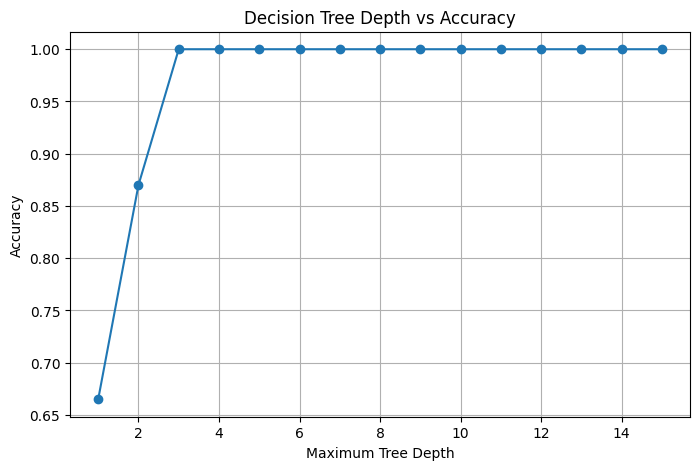

Best Depth: 3
Best Accuracy: 1.0


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    depth_table["Max Depth"],
    depth_table["Accuracy"],
    marker="o"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.grid(True)
plt.show()

best_row = depth_table.loc[
    depth_table["Accuracy"].idxmax()
]

print("Best Depth:", int(best_row["Max Depth"]))
print("Best Accuracy:", best_row["Accuracy"])